In [5]:
import numpy as np
import os
from paths import BASH_PATH

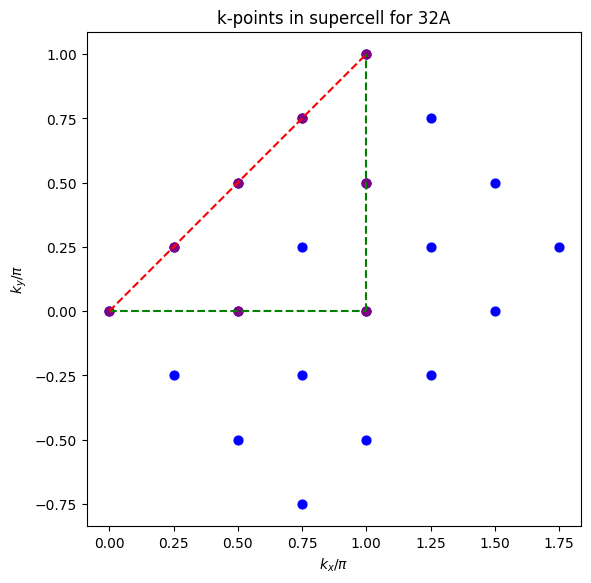

array([[0.  , 0.  ],
       [0.5 , 0.  ],
       [1.  , 0.  ],
       [1.  , 0.5 ],
       [1.  , 1.  ],
       [0.75, 0.75],
       [0.5 , 0.5 ],
       [0.25, 0.25]])

In [1]:
from Betts_cluster import Cluster

c = Cluster(key='32A')
path = c.get_k_space(True)[1]
path

In [ ]:
def write_ham_generator_for_k(n = 24, S_z_tot = 0, delta = 1., lamb = 1., n_workers = 10, kx = 0., ky = 0., memory_GB = 60, hours = 24):

    cpus = int(memory_GB/5)
    key = str(n) + 'A'

    EPSILON = 1e-4

    k_id = ''

    if abs(kx - ky) < EPSILON:
        k_id = f'{int(kx/.25)}{int(ky/.25)}'
    elif ky == 0.:
        k_id = f'{int(kx/.25)}0'
    else:
        k_id = f'4{int(ky/.25)}'

    generic_lines = [
        '#!/bin/bash -l',
        f'#SBATCH --job-name="{n}-{k_id}"',
        "#SBATCH --nodes=1",
        f"#SBATCH --ntasks-per-node={cpus}",
        f"#SBATCH --cpus-per-task=1",
        f"#SBATCH --mem={memory_GB}000",
        f"#SBATCH --time={hours}:00:00",
        "#SBATCH --account=G103-2489",
        "#SBATCH --partition=topola",
        f'#SBATCH --output="results_{n}-{k_id}.out"',
        "",
        "source ./py_venv/bin/activate",
        f"python3 generate_ham.py {key} {S_z_tot} {delta} {lamb} {n_workers} {kx} {ky}"
    ]

    with open(rf'{BASH_PATH}/runner_{key}_{S_z_tot}_{delta}_{lamb}_{round(kx, 2)}_{round(ky, 2)}.batch', 'x') as file:
        for line in generic_lines:
            file.write(line)
            file.write('\n')

In [ ]:
for point in path:
    kx, ky = point
    try:   
        write_ham_generator_for_k(n = 32, S_z_tot=1, kx=kx, ky=ky, memory_GB=60, hours=24)
    except:
        FileExistsError('The batch processor was already created. Delete it to overwrite.')

In [ ]:
def write_ham_generator(n = 32, S_z_tot = 0, delta = 1., lamb = 1., n_workers = 10, memory_GB = 60, hours = 24):

    cpus = int(memory_GB/5)
    key = str(n) + 'A'

    from Betts_cluster import Cluster

    c = Cluster(key=key)
    path = c.get_k_space()[1]


    generic_lines = [
        '#!/bin/bash -l',
        f'#SBATCH --job-name="{n}-{str(delta*10)[:2]}-{str(lamb*10)[:2]}"',
        "#SBATCH --nodes=1",
        f"#SBATCH --ntasks-per-node={cpus}",
        f"#SBATCH --cpus-per-task=1",
        f"#SBATCH --mem={memory_GB}000",
        f"#SBATCH --time={hours}:00:00",
        "#SBATCH --account=G103-2489",
        "#SBATCH --partition=topola",
        f'#SBATCH --output="results_{n}-{str(delta)[:3]}-{str(lamb)[:3]}.out"',
        "",
        "source ./py_venv/bin/activate"
    ]

    for k in path:
        kx, ky = k
        generic_lines.append(f"python3 generate_ham.py {key} {S_z_tot} {delta} {lamb} {n_workers} {kx} {ky}")

    with open(rf'{BASH_PATH}/runner_{key}_{S_z_tot}_{delta}_{lamb}.batch', 'x') as file:
        for line in generic_lines:
            file.write(line)
            file.write('\n')

In [19]:
try:
    write_ham_generator(n = 24, S_z_tot=1, memory_GB=10, hours=4)
except:
    FileExistsError('The batch processor was already created. Delete it to overwrite.')

In [ ]:
try:
    write_ham_generator(n = 32, S_z_tot=1, memory_GB=60, hours=24)
except:
    FileExistsError('The batch processor was already created. Delete it to overwrite.')

In [18]:
try:
    write_ham_generator_for_k(n = 32, S_z_tot=0, kx=0, ky=0, memory_GB=60, hours=6)
except:
    FileExistsError('The batch processor was already created. Delete it to overwrite.')

In [ ]:
try:
    write_ham_generator_for_k(n = 24, S_z_tot=0, kx=0, ky=0, memory_GB=10, hours=1)
except:
    FileExistsError('The batch processor was already created. Delete it to overwrite.')